# NER Analysis of Equity-Related Public Health Discourse

IDS 570: Text as Data — Final Project

## Overview

This notebook performs Named Entity Recognition (NER) analysis to identify and catalog organizations (ORG), geographic locations (GPE), and persons (PERSON) mentioned in proximity to equity-related terms across four document types: academic, policy, NGO, and news. The analysis uses spaCy's pre-trained NER model to extract entities from a corpus of equity-related health discourse, then aggregates and visualizes patterns by document type and equity term.

The sentence-level corpus uses source categories such as `federal_policy`, `state_local`, `ngo_nonprofit`, and `news_commentary`. This notebook collapses those into broader document types: academic → `academic`; federal_policy and state_local → `policy`; ngo_nonprofit → `NGO`; news_commentary → `news`.

## Objectives

- Identify which named entities co-occur with equity terminology across document types
- Analyze distribution of entity types (ORG, GPE, PERSON) in equity-related contexts
- Compare entity patterns between academic, policy, NGO, and news commentary documents
- Normalize findings across document types to account for corpus imbalance
- Export results for downstream visualization in Tableau

## Dataset Description

The input data is `full_sentence_corpus.csv`, which contains sentence-level text segments extracted from public health documents with metadata including document type, source category, and whether the sentence contains equity-related terms.

Input: `01_data/full_sentence_corpus.csv`

Outputs:
- Entity frequency tables by document type and entity label
- Normalized rates (entities per 1,000 equity contexts)
- Visualization dashboards for exploration in Tableau
- Summary statistics tables

## Key Considerations

- **NER Model**: Uses spaCy's en_core_web_md model, a general English model that may miss domain-specific entities in health/policy contexts
- **Entity Context**: Entities are extracted from full sentences, not just the immediate equity term context
- **Normalization**: Raw counts are normalized by 1,000 equity occurrences within each document type to account for corpus imbalance
- **Data Quality**: Document type classification relies on source category mapping defined in this notebook

## Outcome

This notebook produces entity frequency tables and normalized rates that reveal which organizations, locations, and individuals are mentioned in equity-related public health discourse, segmented by document type. These findings enable identification of institutional actors and geographic patterns in different types of health policy discourse.

In [ ]:
from pathlib import Path
from collections import Counter
import re
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", palette="colorblind")

TARGET_TERMS = ["equity", "equitable", "inequity", "inequitable"]
FOCUS_LABELS = ["ORG", "GPE", "PERSON"]
DOC_TYPE_ORDER = ["academic", "policy", "NGO", "news"]
DOC_TYPE_COLORS = {
    "academic": "#1f4e79",
    "policy": "#e07a1f",
    "NGO": "#2a9d8f",
    "news": "#c44536",
}

In [ ]:
# --- PATH & COLUMN DETECTION ---
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "01_data").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root that contains the 01_data folder."
    )


def detect_column(columns, candidates, required=True):
    column_lookup = {column.lower(): column for column in columns}
    for candidate in candidates:
        if candidate.lower() in column_lookup:
            return column_lookup[candidate.lower()]
    if required:
        raise KeyError(f"Missing required column. Expected one of: {candidates}")
    return None


# --- DOCUMENT TYPE MAPPING ---
def map_project_doc_type(value):
    text = "" if pd.isna(value) else str(value).strip().lower()
    mapping = {
        "academic": "academic",
        "federal_policy": "policy",
        "state_local": "policy",
        "policy": "policy",
        "policy_report": "policy",
        "ngo_nonprofit": "NGO",
        "ngo": "NGO",
        "nonprofit": "NGO",
        "news_commentary": "news",
        "news": "news",
        "commentary": "news",
    }
    for key, val in mapping.items():
        if key in text:
            return val
    return "other"


# --- SPACY MODEL LOADING ---
def load_spacy_model():
    models = ["en_core_web_lg", "en_core_web_md", "en_core_web_sm"]
    for model_name in models:
        try:
            return spacy.load(model_name), model_name
        except OSError:
            continue
    raise OSError(
        "No spaCy English model was found. Install one with: python -m spacy download en_core_web_sm"
    )


# --- KEYWORD EXTRACTION ---
def extract_first_keyword(text):
    lowered = str(text).lower()
    for term in TARGET_TERMS:
        if term in lowered:
            return term
    return None

In [ ]:
# --- ENTITY EXTRACTION ---
def build_entity_dataset(frame, text_col, doc_id_col, raw_doc_type_col, nlp):
    metadata_columns = [
        col
        for col in [
            doc_id_col,
            raw_doc_type_col,
            "project_document_type",
            "sentence_id",
            "title",
            "source_label",
            "url",
        ]
        if col in frame.columns
    ]

    records = []
    text_stream = frame[text_col].fillna("").astype(str)
    row_stream = frame[metadata_columns + [text_col]].to_dict("records")

    for row, doc in zip(row_stream, nlp.pipe(text_stream, batch_size=64)):
        for entity in doc.ents:
            entity_text = entity.text.strip()
            records.append(
                {
                    doc_id_col: row.get(doc_id_col),
                    "sentence_id": row.get("sentence_id"),
                    "raw_document_type": row.get(raw_doc_type_col),
                    "project_document_type": row.get("project_document_type"),
                    "title": row.get("title"),
                    "source_label": row.get("source_label"),
                    "url": row.get("url"),
                    "source_text": row.get(text_col),
                    "matched_keyword": extract_first_keyword(row.get(text_col, "")),
                    "entity_text": entity_text,
                    "entity_key": entity_text.lower(),
                    "entity_label": entity.label_,
                    "entity_start_char": entity.start_char,
                    "entity_end_char": entity.end_char,
                }
            )

    return pd.DataFrame(records)

In [ ]:
# --- SUMMARY AGGREGATION ---
def summarize_top_entities(
    entity_frame,
    contexts_per_type,
    documents_per_type,
    doc_id_col,
    label=None,
    top_n=10,
):
    summary_frame = entity_frame.copy()
    if label is not None:
        summary_frame = summary_frame[summary_frame["entity_label"] == label].copy()

    grouped = (
        summary_frame.groupby(["project_document_type", "entity_label", "entity_key"])
        .agg(
            mention_count=("entity_text", "size"),
            unique_contexts=("sentence_id", pd.Series.nunique),
            unique_documents=(doc_id_col, pd.Series.nunique),
            example_entity=(
                "entity_text",
                lambda series: Counter(series).most_common(1)[0][0],
            ),
        )
        .reset_index()
    )
    grouped["contexts_in_type"] = grouped["project_document_type"].map(
        contexts_per_type
    )
    grouped["documents_in_type"] = grouped["project_document_type"].map(
        documents_per_type
    )
    grouped["mentions_per_1000_contexts"] = (
        grouped["mention_count"] / grouped["contexts_in_type"] * 1000
    ).round(2)
    grouped["context_share_within_type"] = (
        grouped["unique_contexts"] / grouped["contexts_in_type"]
    ).round(4)
    grouped = grouped.sort_values(
        ["project_document_type", "mention_count", "unique_contexts"],
        ascending=[True, False, False],
    )
    return (
        grouped.groupby("project_document_type", group_keys=False)
        .head(top_n)
        .reset_index(drop=True)
    )

In [ ]:
# --- VISUALIZATION ---
def plot_top_entities_by_type(
    summary_frame, plot_title, x_column="mention_count", top_n=8
):
    fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
    axes = axes.flatten()

    for axis, doc_type in zip(axes, DOC_TYPE_ORDER):
        subset = (
            summary_frame[summary_frame["project_document_type"] == doc_type]
            .head(top_n)
            .copy()
        )
        subset = subset.sort_values(x_column, ascending=True)
        sns.barplot(
            data=subset,
            x=x_column,
            y="example_entity",
            color=DOC_TYPE_COLORS[doc_type],
            ax=axis,
        )
        axis.set_title(doc_type if doc_type == "NGO" else doc_type.title(), fontsize=12)
        axis.set_xlabel(x_column.replace("_", " ").title())
        axis.set_ylabel("Entity")

    fig.suptitle(plot_title, fontsize=16, y=1.02)
    return fig

## 2. Load and Inspect Data

This section loads the sentence-level corpus, detects the core columns automatically, and checks the data structure before filtering to equity-related contexts.

In [ ]:
# --- LOAD DATA ---
PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_CANDIDATES = [
    PROJECT_ROOT / "01_data" / "full_sentence_corpus.csv",
    PROJECT_ROOT / "01_data" / "validated_dataset.csv",
]
DATASET_PATH = next((path for path in DATASET_CANDIDATES if path.exists()), None)

analysis_df = pd.read_csv(DATASET_PATH)
TEXT_COLUMN = detect_column(
    analysis_df.columns, ["sentence_text", "text", "sentence", "context_window"]
)
DOC_ID_COLUMN = detect_column(analysis_df.columns, ["document_id", "doc_id", "id"])
RAW_DOC_TYPE_COLUMN = detect_column(
    analysis_df.columns, ["category", "document_type", "doc_type", "source_type"]
)
SENTENCE_ID_COLUMN = detect_column(
    analysis_df.columns, ["sentence_id", "context_id", "row_id"], required=False
)

analysis_df[TEXT_COLUMN] = analysis_df[TEXT_COLUMN].fillna("").astype(str)
analysis_df["project_document_type"] = analysis_df[RAW_DOC_TYPE_COLUMN].map(
    map_project_doc_type
)
analysis_df["project_document_type"] = pd.Categorical(
    analysis_df["project_document_type"],
    categories=DOC_TYPE_ORDER + ["other"],
    ordered=True,
)

preview_columns = [
    column
    for column in [
        DOC_ID_COLUMN,
        SENTENCE_ID_COLUMN,
        RAW_DOC_TYPE_COLUMN,
        TEXT_COLUMN,
        "title",
        "source_label",
    ]
    if column is not None and column in analysis_df.columns
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset selected: {DATASET_PATH.relative_to(PROJECT_ROOT)}")
print(f"Dataset shape: {analysis_df.shape}")
print(f"Configured text column: {TEXT_COLUMN}")
print(f"Configured document ID column: {DOC_ID_COLUMN}")
print(f"Configured raw document-type column: {RAW_DOC_TYPE_COLUMN}")
display(analysis_df[preview_columns].head(5))

Project root: /Users/far/IDS570_Text_as_Data_final_Project
Dataset selected: 01_data/full_sentence_corpus.csv
Dataset shape: (27365, 22)
Configured text column: sentence_text
Configured document ID column: document_id
Configured raw document-type column: category


,document_id,sentence_id,category,sentence_text,title,source_label
0,doc_2d830432db58,doc_2d830432db58_s00000,federal_policy,eveloping Health Equity Measures Prepared for the Office of the Assistant Secretary for Planning and Evaluation (ASP...,Developing Health Equity Measures,ASPE / HHS
1,doc_2d830432db58,doc_2d830432db58_s00001,federal_policy,"ASPE leads special initiatives; coordinates the Department's evaluation, research, and demonstration activities; and...",Developing Health Equity Measures,ASPE / HHS
2,doc_2d830432db58,doc_2d830432db58_s00002,federal_policy,"Integral to this role, ASPE conducts research and evaluation studies; develops policy analyses; and estimates the co...",Developing Health Equity Measures,ASPE / HHS
3,doc_2d830432db58,doc_2d830432db58_s00003,federal_policy,Office of Health Policy The Office of Health Policy (HP) provides a cross-cutting policy perspective that bridges De...,Developing Health Equity Measures,ASPE / HHS
4,doc_2d830432db58,doc_2d830432db58_s00004,federal_policy,"HP carries out this mission by conducting policy, economic and budget analyses, assisting in the development and rev...",Developing Health Equity Measures,ASPE / HHS


In [7]:
# We inspect data quality and show the document-type imbalance before running NER.
inspection_columns = [
    column
    for column in [
        DOC_ID_COLUMN,
        RAW_DOC_TYPE_COLUMN,
        TEXT_COLUMN,
        "title",
        "source_label",
        SENTENCE_ID_COLUMN,
    ]
    if column is not None and column in analysis_df.columns
]
missing_summary = (
    analysis_df[inspection_columns].isna().sum().rename("missing_values").reset_index()
)
missing_summary = missing_summary.rename(columns={"index": "column"})

raw_sentence_distribution = (
    analysis_df[RAW_DOC_TYPE_COLUMN]
    .value_counts(dropna=False)
    .rename("sentence_rows")
    .reset_index()
)
raw_sentence_distribution = raw_sentence_distribution.rename(
    columns={"index": "raw_document_type"}
)

project_sentence_distribution = (
    analysis_df["project_document_type"]
    .value_counts(dropna=False)
    .rename("sentence_rows")
    .reset_index()
)
project_sentence_distribution = project_sentence_distribution.rename(
    columns={"index": "project_document_type"}
)

project_document_distribution = (
    analysis_df.groupby("project_document_type", observed=False)[DOC_ID_COLUMN]
    .nunique()
    .rename("unique_documents")
    .reset_index()
    .sort_values("project_document_type")
)

imbalance_table = project_sentence_distribution.merge(
    project_document_distribution,
    on="project_document_type",
    how="left",
)
imbalance_table["sentence_share_pct"] = (
    imbalance_table["sentence_rows"] / imbalance_table["sentence_rows"].sum() * 100
).round(2)

print("Missing values in key columns:")
display(missing_summary)

print("Raw category distribution (sentence rows):")
display(raw_sentence_distribution)

print("Project document-type distribution after mapping categories:")
display(imbalance_table)

policy_note = "Policy aggregates federal_policy and state_local to align with the project framing."
dominant_type = imbalance_table.sort_values("sentence_rows", ascending=False).iloc[0][
    "project_document_type"
]
print(policy_note)
print(f"The largest document type in the sentence-level corpus is: {dominant_type}")
print(
    "This imbalance is why the notebook reports both raw counts and normalized rates per 1,000 equity-related contexts."
)

Missing values in key columns:


,column,missing_values
0,document_id,0
1,category,0
2,sentence_text,0
3,title,0
4,source_label,24
5,sentence_id,0


Raw category distribution (sentence rows):


,category,sentence_rows
0,state_local,12337
1,federal_policy,8533
2,ngo_nonprofit,5581
3,news_commentary,483
4,academic,431


Project document-type distribution after mapping categories:


,project_document_type,sentence_rows,unique_documents,sentence_share_pct
0,policy,20870,39,76.270
1,NGO,5581,17,20.390
2,news,483,23,1.770
3,academic,431,49,1.580
4,other,0,0,0.000


Policy aggregates federal_policy and state_local to align with the project framing.
The largest document type in the sentence-level corpus is: policy
This imbalance is why the notebook reports both raw counts and normalized rates per 1,000 equity-related contexts.


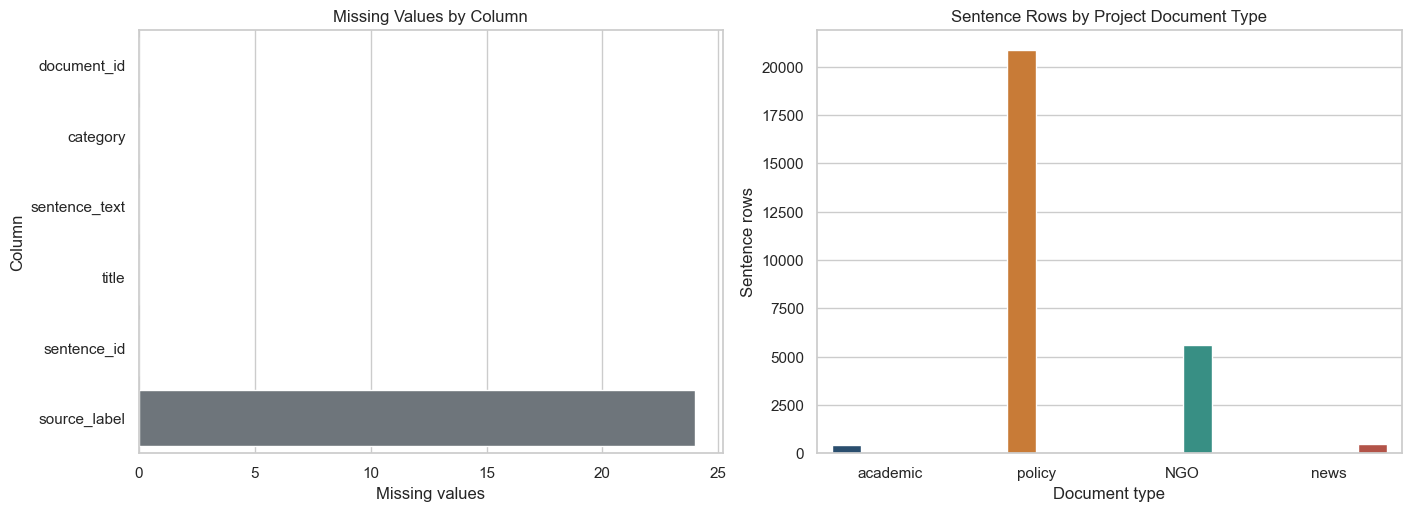

In [8]:
# --- VISUALIZE MISSINGNESS & CORPUS IMBALANCE ---
plot_missing = missing_summary.sort_values("missing_values", ascending=True).copy()
plot_imbalance = imbalance_table[
    imbalance_table["project_document_type"].isin(DOC_TYPE_ORDER)
].copy()
plot_imbalance["project_document_type"] = plot_imbalance[
    "project_document_type"
].cat.remove_unused_categories()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.barplot(
    data=plot_missing,
    x="missing_values",
    y="column",
    color="#6c757d",
    ax=axes[0],
)
axes[0].set_title("Missing Values by Column")
axes[0].set_xlabel("Missing values")
axes[0].set_ylabel("Column")

sns.barplot(
    data=plot_imbalance,
    x="project_document_type",
    y="sentence_rows",
    hue="project_document_type",
    palette=DOC_TYPE_COLORS,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Sentence Rows by Project Document Type")
axes[1].set_xlabel("Document type")
axes[1].set_ylabel("Sentence rows")

plt.show()

## 3. Filter Equity-Related Contexts

This section keeps only the sentence-level contexts that mention the target terms `equity`, `equitable`, `inequity`, or `inequitable`.

In [9]:
# --- FILTER EQUITY CONTEXTS ---
equity_pattern = re.compile(
    r"\b(?:equity|equitable|inequity|inequitable)\b", flags=re.IGNORECASE
)
analysis_df["matched_terms"] = analysis_df[TEXT_COLUMN].str.findall(equity_pattern)
filtered_df = analysis_df[analysis_df["matched_terms"].map(len) > 0].copy()
filtered_df["matched_keyword"] = filtered_df["matched_terms"].map(
    lambda terms: sorted({term.lower() for term in terms})[0] if terms else None
)
filtered_df["project_document_type"] = pd.Categorical(
    filtered_df["project_document_type"],
    categories=DOC_TYPE_ORDER + ["other"],
    ordered=True,
)

keyword_distribution = (
    filtered_df["matched_keyword"]
    .value_counts(dropna=False)
    .rename("matched_rows")
    .reset_index()
)
keyword_distribution = keyword_distribution.rename(columns={"index": "matched_keyword"})

filtered_type_distribution = (
    filtered_df["project_document_type"]
    .value_counts(dropna=False)
    .rename("equity_context_rows")
    .reset_index()
)
filtered_type_distribution = filtered_type_distribution.rename(
    columns={"index": "project_document_type"}
)

match_share = len(filtered_df) / len(analysis_df) if len(analysis_df) else 0
sample_columns = [
    column
    for column in [
        DOC_ID_COLUMN,
        SENTENCE_ID_COLUMN,
        "project_document_type",
        "matched_keyword",
        TEXT_COLUMN,
    ]
    if column is not None and column in filtered_df.columns
]

print(f"Equity-related rows matched: {len(filtered_df):,}")
print(f"Share of the full corpus retained: {match_share:.2%}")
display(keyword_distribution)
display(filtered_type_distribution)
print("Sample equity-related contexts:")
display(filtered_df[sample_columns].head(8))

Equity-related rows matched: 4,406
Share of the full corpus retained: 16.10%


,matched_keyword,matched_rows
0,equity,3967
1,equitable,327
2,inequity,91
3,inequitable,21


,project_document_type,equity_context_rows
0,policy,3498
1,NGO,709
2,academic,145
3,news,54
4,other,0


Sample equity-related contexts:


,document_id,sentence_id,project_document_type,matched_keyword,sentence_text
0,doc_2d830432db58,doc_2d830432db58_s00000,policy,equity,eveloping Health Equity Measures Prepared for the Office of the Assistant Secretary for Planning and Evaluation (ASP...
8,doc_2d830432db58,doc_2d830432db58_s00008,policy,equity,This included the recommendations that the Centers for Medicare and Medicaid Services (CMS) include measures of heal...
9,doc_2d830432db58,doc_2d830432db58_s00009,policy,equity,"Moreover, in the ASPE commissioned report, Systems Practices for the Care of Socially At-Risk Populations, the Natio..."
10,doc_2d830432db58,doc_2d830432db58_s00010,policy,equity,"In response to this challenge, ASPE asked the RAND Corporation to develop a proposed definition of health equity as ..."
11,doc_2d830432db58,doc_2d830432db58_s00011,policy,equity,RAND identified 10 existing approaches to health equity measurement and convened a technical expert panel (TEP) to: ...
12,doc_2d830432db58,doc_2d830432db58_s00012,policy,equity,"Based on input from RAND, ASPE, and the TEP, in this report RAND defines a health equity measurement approach as ""an..."
14,doc_2d830432db58,doc_2d830432db58_s00014,policy,equity,The purpose of including health equity measurement approaches in VBP programs and quality reporting efforts is to mo...
15,doc_2d830432db58,doc_2d830432db58_s00015,policy,equity,"It could also encourage providers to improve health equity through service enhancements, patient engagement activiti..."


ValueError: The palette dictionary is missing keys: {'other'}

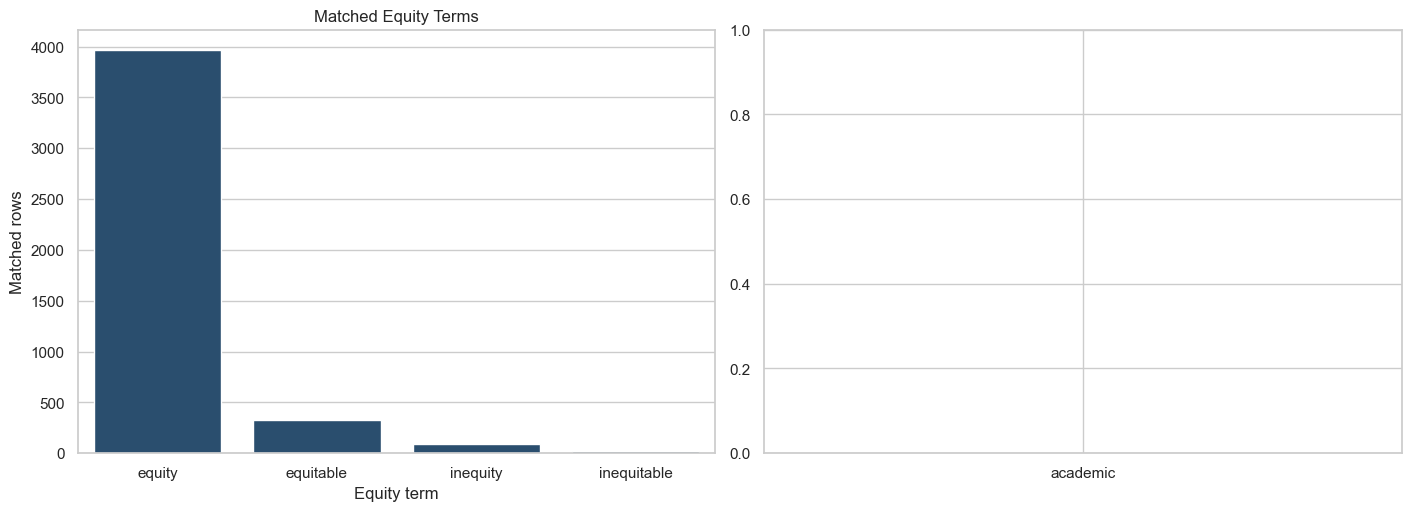

In [ ]:
# --- VISUALIZE EQUITY TERM & TYPE DISTRIBUTIONS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.barplot(
    data=keyword_distribution,
    x="matched_keyword",
    y="matched_rows",
    color="#1f4e79",
    ax=axes[0],
)
axes[0].set_title("Matched Equity Terms")
axes[0].set_xlabel("Equity term")
axes[0].set_ylabel("Matched rows")

plot_filtered_type = filtered_type_distribution[
    filtered_type_distribution["project_document_type"].isin(DOC_TYPE_ORDER)
].copy()
plot_filtered_type["project_document_type"] = plot_filtered_type[
    "project_document_type"
].cat.remove_unused_categories()
sns.barplot(
    data=plot_filtered_type,
    x="project_document_type",
    y="equity_context_rows",
    hue="project_document_type",
    palette=DOC_TYPE_COLORS,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Equity Contexts by Document Type")
axes[1].set_xlabel("Document type")
axes[1].set_ylabel("Equity context rows")

plt.show()

## 4. Run spaCy NER

This section loads a spaCy English model and extracts named entities from the equity-related contexts.

In [ ]:
# We load a spaCy English model and confirm that the NER pipeline is ready.
nlp, SPACY_MODEL_NAME = load_spacy_model()
pipe_names = ", ".join(nlp.pipe_names)

print(f"Loaded spaCy model: {SPACY_MODEL_NAME}")
print(f"Available pipeline components: {pipe_names}")
print(
    "The notebook prefers larger English models when available and falls back to en_core_web_sm when needed."
)

Loaded spaCy model: en_core_web_sm
Available pipeline components: tok2vec, tagger, parser, attribute_ruler, lemmatizer, ner
The notebook prefers larger English models when available and falls back to en_core_web_sm when needed.


In [ ]:
# We run spaCy NER on the filtered contexts and build a long-format entity dataset.
entity_df = build_entity_dataset(
    filtered_df, TEXT_COLUMN, DOC_ID_COLUMN, RAW_DOC_TYPE_COLUMN, nlp
)

entity_df["project_document_type"] = pd.Categorical(
    entity_df["project_document_type"],
    categories=DOC_TYPE_ORDER + ["other"],
    ordered=True,
)
entity_df["entity_label"] = entity_df["entity_label"].astype(str)
contexts_with_entities = (
    entity_df["sentence_id"].nunique()
    if "sentence_id" in entity_df.columns
    else len(filtered_df)
)
unique_entities = entity_df["entity_key"].nunique()

print(f"Filtered contexts processed: {len(filtered_df):,}")
print(f"Entity mentions extracted: {len(entity_df):,}")
print(f"Unique normalized entities: {unique_entities:,}")
print(f"Contexts with at least one entity: {contexts_with_entities:,}")

preview_columns = [
    column
    for column in [
        "project_document_type",
        "matched_keyword",
        "entity_text",
        "entity_label",
        "title",
    ]
    if column in entity_df.columns
]
display(entity_df[preview_columns].head(12))

Filtered contexts processed: 4,406
Entity mentions extracted: 9,934
Unique normalized entities: 5,315
Contexts with at least one entity: 3,191


,project_document_type,matched_keyword,entity_text,entity_label,title
0,policy,equity,Health Equity Measures Prepared,ORG,Developing Health Equity Measures
1,policy,equity,the Office of the Assistant,ORG,Developing Health Equity Measures
2,policy,equity,Planning and Evaluation,ORG,Developing Health Equity Measures
3,policy,equity,the U.S. Department of Health & Human Services,ORG,Developing Health Equity Measures
4,policy,equity,RAND H,ORG,Developing Health Equity Measures
5,policy,equity,Care May 2021 Office of the Assistant,ORG,Developing Health Equity Measures
6,policy,equity,Planning and Evaluation,ORG,Developing Health Equity Measures
7,policy,equity,Planning and Evaluation,ORG,Developing Health Equity Measures
8,policy,equity,the U.S. Department of Health and Human Services,ORG,Developing Health Equity Measures
9,policy,equity,HHS,ORG,Developing Health Equity Measures


## 5. Build Entity-Level Dataset

The entity-level table below is the core long-format dataset used for the rest of the analysis. Each row represents one named entity mention found inside an equity-related sentence.

In [ ]:
# We summarize all entity labels first and then isolate the ORG, GPE, and PERSON subsets.
overall_label_freq = (
    entity_df["entity_label"].value_counts().rename("mentions").reset_index()
)
overall_label_freq = overall_label_freq.rename(columns={"index": "entity_label"})
overall_label_freq["share_pct"] = (
    overall_label_freq["mentions"] / overall_label_freq["mentions"].sum() * 100
).round(2)

label_order = overall_label_freq["entity_label"].tolist()
label_by_type_counts = pd.crosstab(
    entity_df["project_document_type"], entity_df["entity_label"]
).reindex(DOC_TYPE_ORDER, fill_value=0)
label_by_type_counts = label_by_type_counts.reindex(columns=label_order, fill_value=0)

label_by_type_props = pd.crosstab(
    entity_df["project_document_type"],
    entity_df["entity_label"],
    normalize="index",
).reindex(DOC_TYPE_ORDER, fill_value=0)
label_by_type_props = label_by_type_props.reindex(
    columns=label_order, fill_value=0
).round(3)

focus_entity_df = entity_df[entity_df["entity_label"].isin(FOCUS_LABELS)].copy()
focus_counts = pd.crosstab(
    focus_entity_df["project_document_type"], focus_entity_df["entity_label"]
).reindex(DOC_TYPE_ORDER, fill_value=0)

print("Overall entity label frequencies:")
display(overall_label_freq.head(15))

print("Entity label counts by document type:")
display(label_by_type_counts.iloc[:, :10])

print("Entity label proportions within each document type:")
display(label_by_type_props.iloc[:, :10])

print("Focused counts for ORG, GPE, and PERSON:")
display(focus_counts)

Overall entity label frequencies:


,entity_label,mentions,share_pct
0,ORG,6161,62.020
1,PERSON,1059,10.660
2,GPE,887,8.930
3,DATE,579,5.830
4,CARDINAL,394,3.970
5,NORP,215,2.160
6,WORK_OF_ART,174,1.750
7,ORDINAL,106,1.070
8,PRODUCT,74,0.740
9,PERCENT,62,0.620


Entity label counts by document type:


entity_label,ORG,PERSON,GPE,DATE,CARDINAL,NORP,WORK_OF_ART,ORDINAL,PRODUCT,PERCENT
project_document_type,,,,,,,,,,
academic,44,4,11,6,9,0,0,4,0,0
policy,4992,687,706,409,305,172,82,82,56,50
NGO,1078,336,167,151,75,38,92,19,18,12
news,47,32,3,13,5,5,0,1,0,0


Entity label proportions within each document type:


entity_label,ORG,PERSON,GPE,DATE,CARDINAL,NORP,WORK_OF_ART,ORDINAL,PRODUCT,PERCENT
project_document_type,,,,,,,,,,
academic,0.530,0.048,0.133,0.072,0.108,0.000,0.000,0.048,0.000,0.000
policy,0.646,0.089,0.091,0.053,0.039,0.022,0.011,0.011,0.007,0.006
NGO,0.533,0.166,0.083,0.075,0.037,0.019,0.045,0.009,0.009,0.006
news,0.443,0.302,0.028,0.123,0.047,0.047,0.000,0.009,0.000,0.000


Focused counts for ORG, GPE, and PERSON:


entity_label,GPE,ORG,PERSON
project_document_type,,,
academic,11,44,4
policy,706,4992,687
NGO,167,1078,336
news,3,47,32


In [ ]:
# --- VISUALIZE ENTITY LABEL MIX BY TYPE ---
label_mix_heatmap = label_by_type_props.reindex(DOC_TYPE_ORDER).fillna(0)

plt.figure(figsize=(10, 4.8))
sns.heatmap(
    label_mix_heatmap,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Within-type proportion"},
)
plt.title("Entity Label Proportions by Document Type")
plt.xlabel("Entity label")
plt.ylabel("Document type")
plt.tight_layout()
plt.show()

## 6. Aggregate and Compare Results

These tables compare overall entity activity and the top co-occurring entities across academic, policy, NGO, and news contexts.

In [ ]:
# We compare document types with both raw entity counts and imbalance-adjusted rates.
contexts_per_type = (
    filtered_df.groupby("project_document_type", observed=False)
    .size()
    .reindex(DOC_TYPE_ORDER, fill_value=0)
)
documents_per_type = (
    filtered_df.groupby("project_document_type", observed=False)[DOC_ID_COLUMN]
    .nunique()
    .reindex(DOC_TYPE_ORDER, fill_value=0)
)
entity_mentions_by_type = (
    entity_df.groupby("project_document_type", observed=False)
    .size()
    .reindex(DOC_TYPE_ORDER, fill_value=0)
)

entity_summary_by_type = pd.DataFrame(
    {
        "equity_contexts": contexts_per_type,
        "unique_documents": documents_per_type,
        "entity_mentions": entity_mentions_by_type,
    }
)
entity_summary_by_type["mentions_per_1000_contexts"] = (
    entity_summary_by_type["entity_mentions"]
    / entity_summary_by_type["equity_contexts"]
    * 1000
).round(2)
entity_summary_by_type["share_of_all_entity_mentions_pct"] = (
    entity_summary_by_type["entity_mentions"]
    / entity_summary_by_type["entity_mentions"].sum()
    * 100
).round(2)

overall_top_entities = summarize_top_entities(
    entity_df,
    contexts_per_type.to_dict(),
    documents_per_type.to_dict(),
    DOC_ID_COLUMN,
    label=None,
    top_n=10,
)

print("Entity counts by document type:")
display(
    entity_summary_by_type.reset_index().rename(
        columns={"index": "project_document_type"}
    )
)

print("Top co-occurring entities in each document type:")
display(
    overall_top_entities[
        [
            "project_document_type",
            "example_entity",
            "entity_label",
            "mention_count",
            "unique_contexts",
            "mentions_per_1000_contexts",
        ]
    ]
)

Entity counts by document type:


,project_document_type,equity_contexts,unique_documents,entity_mentions,mentions_per_1000_contexts,share_of_all_entity_mentions_pct
0,academic,145,32,83,572.410,0.840
1,policy,3498,36,7722,"2,207.550",77.730
2,NGO,709,17,2023,"2,853.310",20.360
3,news,54,10,106,"1,962.960",1.070


Top co-occurring entities in each document type:


,project_document_type,example_entity,entity_label,mention_count,unique_contexts,mentions_per_1000_contexts
0,academic,Medicaid,ORG,8,5,55.170
1,academic,US,GPE,5,5,34.480
2,academic,two,CARDINAL,4,4,27.590
3,academic,first,ORDINAL,3,3,20.690
4,academic,HEMF,ORG,3,3,20.690
5,academic,U.S.,GPE,2,2,13.790
6,academic,Abstract Achieving,ORG,2,2,13.790
7,academic,Advance Health Equity,ORG,2,2,13.790
8,academic,DEI,ORG,2,2,13.790
9,academic,Health Equity,ORG,2,2,13.790


Normalized rates are especially important here because policy contexts greatly outnumber the other document types.


In [ ]:
# We create clean summary tables for the top organizations, places, and people in each document type.
top_org = summarize_top_entities(
    entity_df,
    contexts_per_type.to_dict(),
    documents_per_type.to_dict(),
    DOC_ID_COLUMN,
    label="ORG",
    top_n=10,
)
top_gpe = summarize_top_entities(
    entity_df,
    contexts_per_type.to_dict(),
    documents_per_type.to_dict(),
    DOC_ID_COLUMN,
    label="GPE",
    top_n=10,
)
top_person = summarize_top_entities(
    entity_df,
    contexts_per_type.to_dict(),
    documents_per_type.to_dict(),
    DOC_ID_COLUMN,
    label="PERSON",
    top_n=10,
)

top_columns = [
    "project_document_type",
    "example_entity",
    "mention_count",
    "unique_contexts",
    "unique_documents",
    "mentions_per_1000_contexts",
]

print("Top 10 ORG entities by document type:")
display(top_org[top_columns])

print("Top 10 GPE entities by document type:")
display(top_gpe[top_columns])

print("Top 10 PERSON entities by document type:")
display(top_person[top_columns])

Top 10 ORG entities by document type:


,project_document_type,example_entity,mention_count,unique_contexts,unique_documents,mentions_per_1000_contexts
0,academic,Medicaid,8,5,3,55.170
1,academic,HEMF,3,3,1,20.690
2,academic,Abstract Achieving,2,2,2,13.790
3,academic,Advance Health Equity,2,2,1,13.790
4,academic,DEI,2,2,1,13.790
5,academic,Health Equity,2,2,2,13.790
6,academic,NIMHD,2,2,1,13.790
7,academic,QEM,2,2,1,13.790
8,academic,CDC,2,1,1,13.790
9,academic,ACA,1,1,1,6.900


Top 10 GPE entities by document type:


,project_document_type,example_entity,mention_count,unique_contexts,unique_documents,mentions_per_1000_contexts
0,academic,US,5,5,3,34.480
1,academic,U.S.,2,2,2,13.790
2,academic,Inclusion,1,1,1,6.900
3,academic,the United States,1,1,1,6.900
4,academic,the United States of America,1,1,1,6.900
5,academic,USA,1,1,1,6.900
6,policy,King county,53,45,1,15.150
7,policy,Michigan,43,38,2,12.290
8,policy,North Carolina,34,30,3,9.720
9,policy,Pennsylvania,33,27,4,9.430


Top 10 PERSON entities by document type:


,project_document_type,example_entity,mention_count,unique_contexts,unique_documents,mentions_per_1000_contexts
0,academic,Advocacy,1,1,1,6.900
1,academic,Avant,1,1,1,6.900
2,academic,Expanding Medicaid,1,1,1,6.900
3,academic,Healthy People 2020,1,1,1,6.900
4,policy,HCI,30,25,1,8.580
5,policy,COVID-19,17,16,6,4.860
6,policy,Workgroup Recommendations,12,4,1,3.430
7,policy,Healthy People 2030,10,9,5,2.860
8,policy,Roadmap,9,9,1,2.570
9,policy,Healthy People,8,7,3,2.290


The PERSON table is usually the noisiest because sentence-level NER can misclassify programs or acronyms as people in technical policy prose.


In [ ]:
# Save the extracted named entities to a CSV file
output_path = PROJECT_ROOT / "01_data" / "ner_entities.csv"
entity_df.to_csv(output_path, index=False)
print(f"Saved {len(entity_df):,} rows to {output_path.relative_to(PROJECT_ROOT)}")

## 7. Visualizations

These figures translate the tables above into presentation-ready charts for the class project.

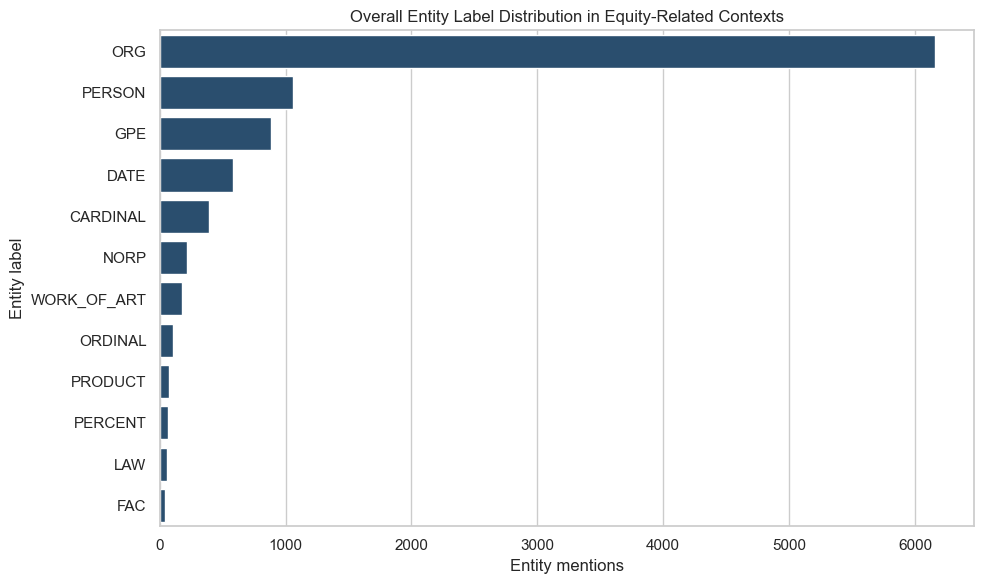

Displayed the top 12 entity labels by raw mention count.


In [ ]:
# We visualize the overall entity label distribution across all equity-related contexts.
label_plot_df = overall_label_freq.head(12).copy()
plt.figure(figsize=(10, 6))
sns.barplot(data=label_plot_df, x="mentions", y="entity_label", color="#1f4e79")
plt.title("Overall Entity Label Distribution in Equity-Related Contexts")
plt.xlabel("Entity mentions")
plt.ylabel("Entity label")
plt.tight_layout()
plt.show()

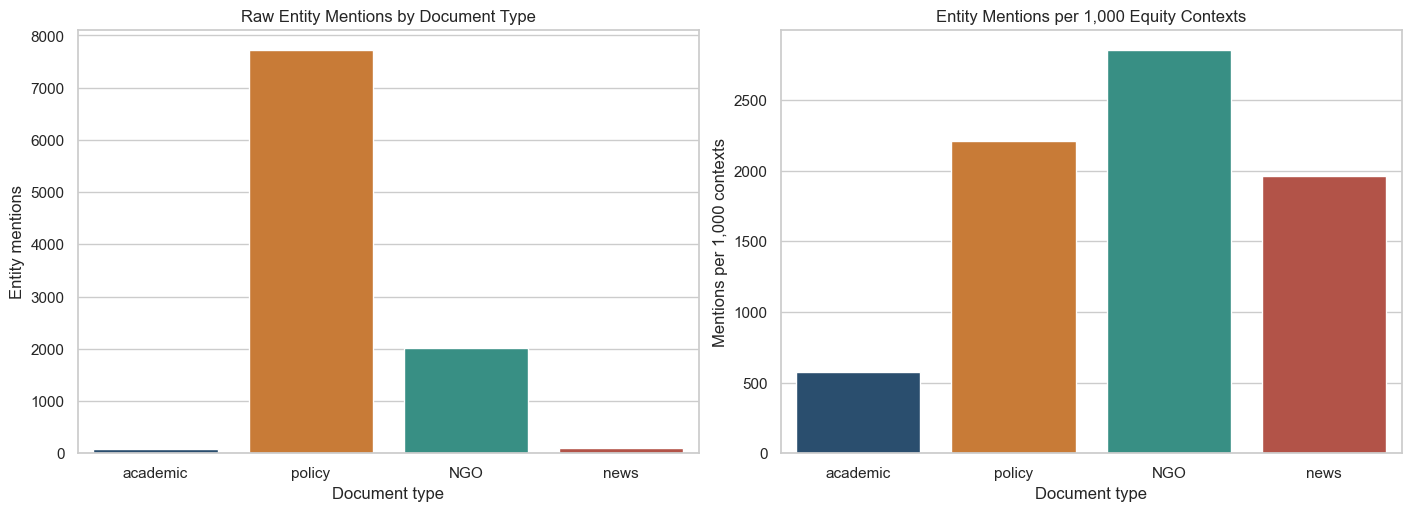

The left panel shows raw counts, while the right panel adjusts for the strong policy-heavy imbalance in the corpus.


In [ ]:
# We compare document types with side-by-side raw and normalized entity-count charts.
plot_summary = entity_summary_by_type.reset_index(names="project_document_type").copy()
plot_summary = plot_summary[plot_summary["project_document_type"].isin(DOC_TYPE_ORDER)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.barplot(
    data=plot_summary,
    x="project_document_type",
    y="entity_mentions",
    hue="project_document_type",
    palette=DOC_TYPE_COLORS,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Raw Entity Mentions by Document Type")
axes[0].set_xlabel("Document type")
axes[0].set_ylabel("Entity mentions")

sns.barplot(
    data=plot_summary,
    x="project_document_type",
    y="mentions_per_1000_contexts",
    hue="project_document_type",
    palette=DOC_TYPE_COLORS,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Entity Mentions per 1,000 Equity Contexts")
axes[1].set_xlabel("Document type")
axes[1].set_ylabel("Mentions per 1,000 contexts")

plt.show()

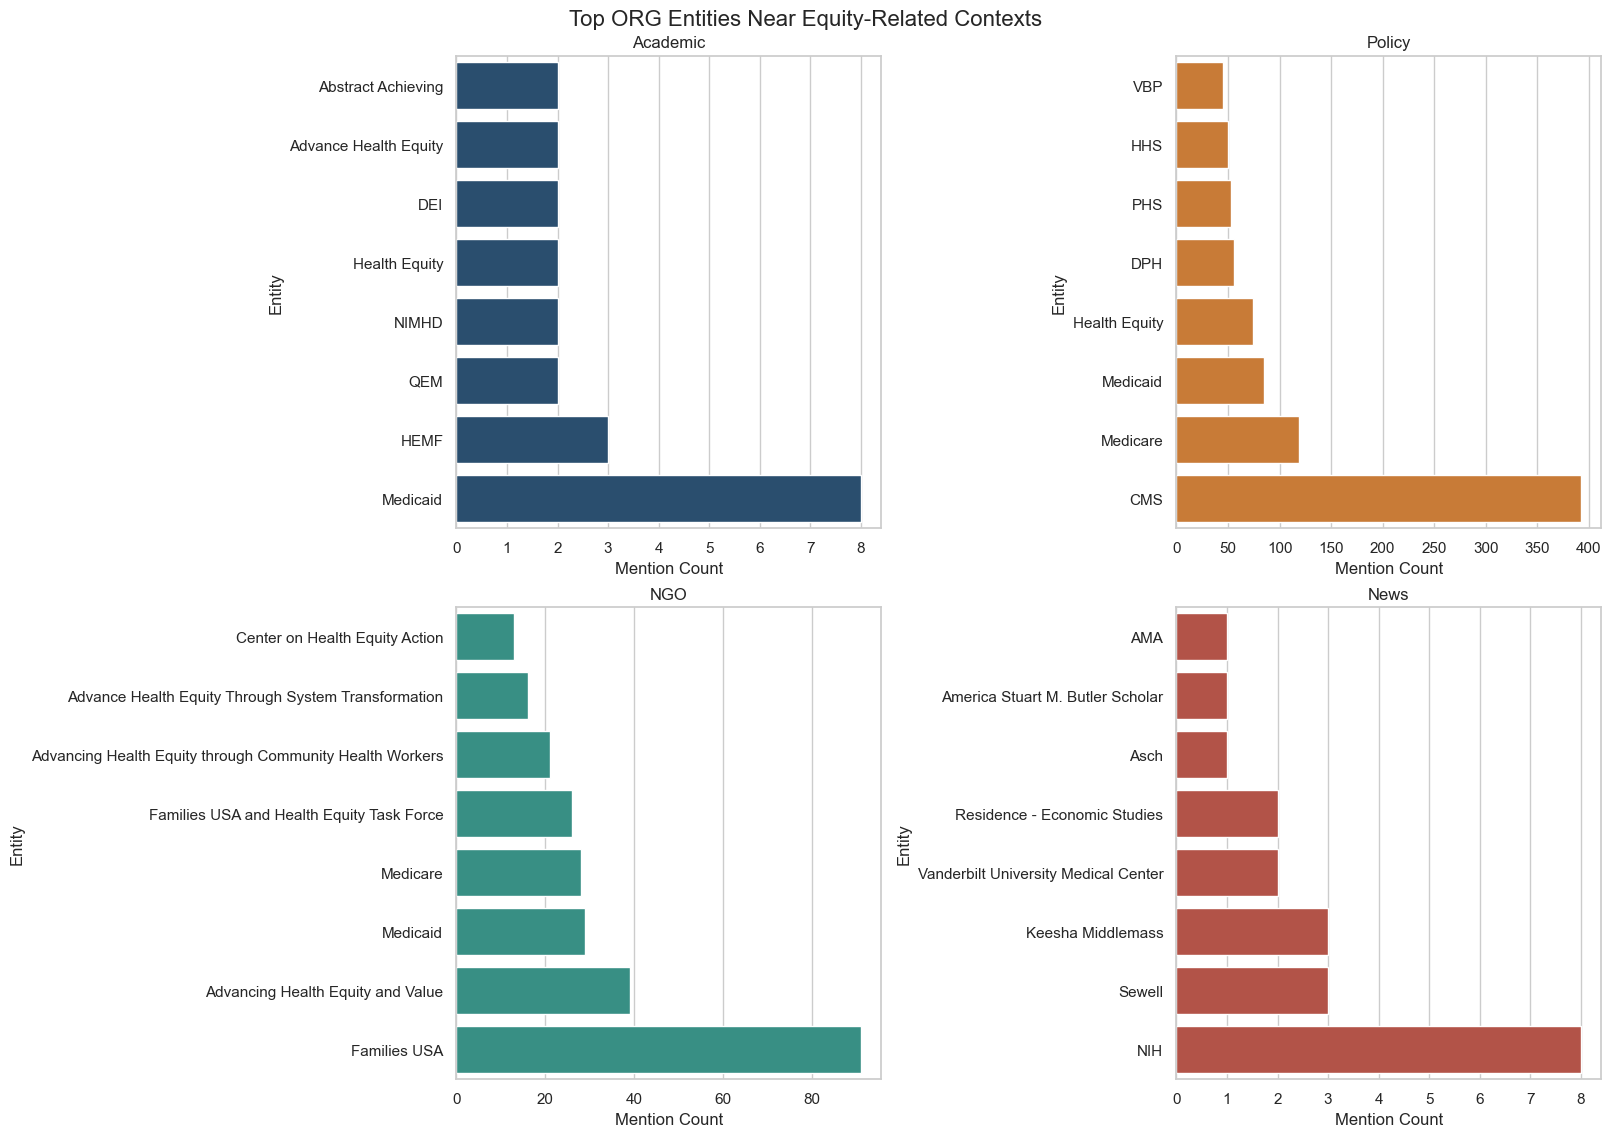

Each panel shows the leading organizations within one document type using raw mention counts.


In [ ]:
# We plot the most frequent organizations within each document type.
org_figure = plot_top_entities_by_type(
    top_org,
    plot_title="Top ORG Entities Near Equity-Related Contexts",
    x_column="mention_count",
    top_n=8,
)
plt.show()

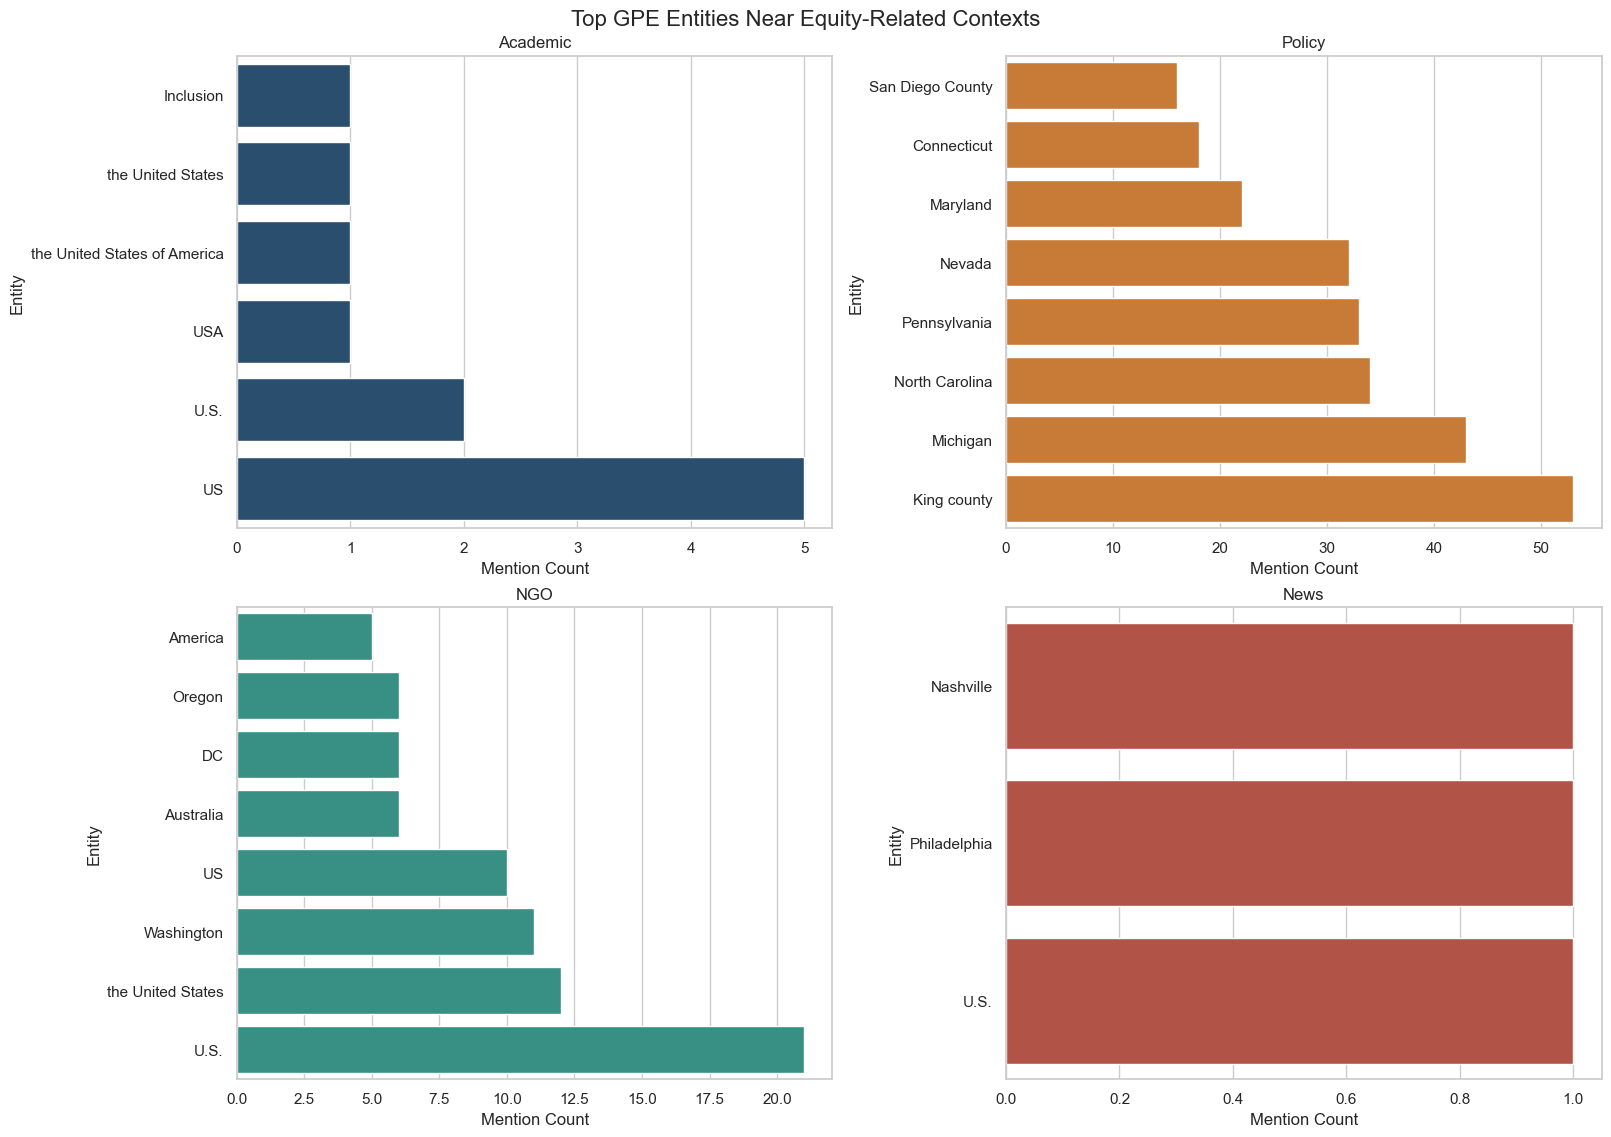

These panels highlight the main geographic references attached to equity-related language.


In [ ]:
# We plot the most frequent places within each document type.
gpe_figure = plot_top_entities_by_type(
    top_gpe,
    plot_title="Top GPE Entities Near Equity-Related Contexts",
    x_column="mention_count",
    top_n=8,
)
plt.show()

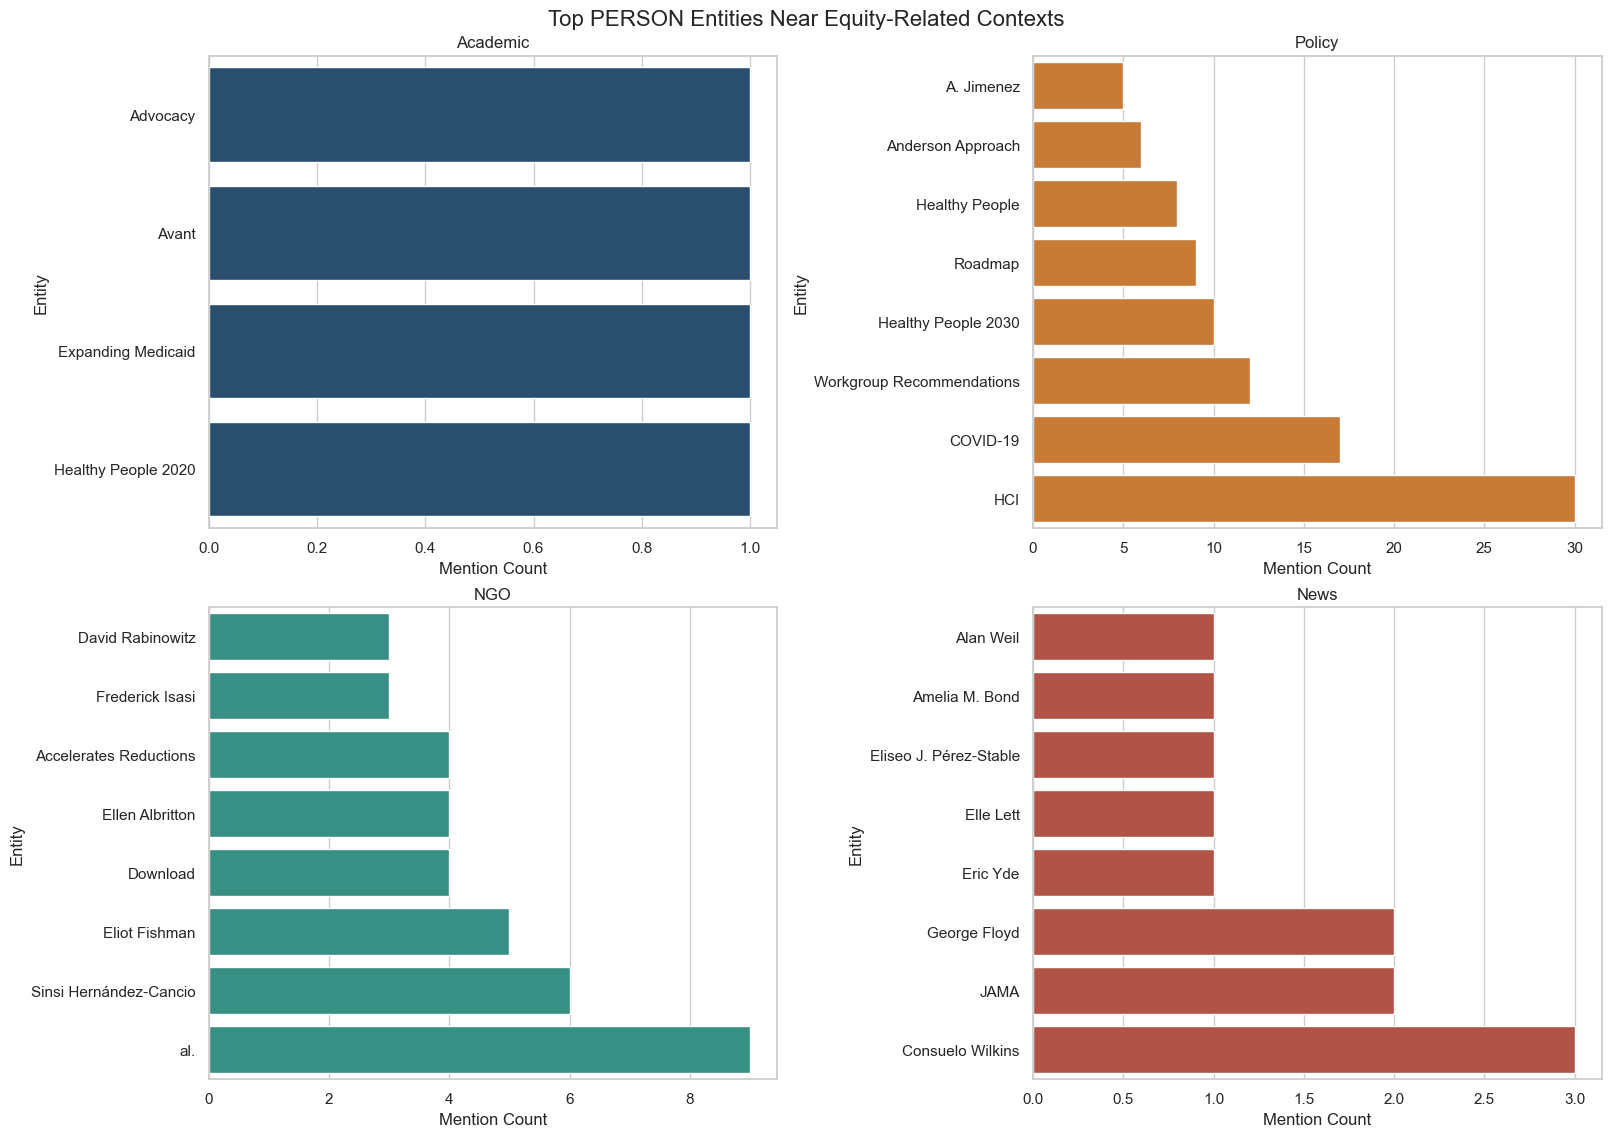

PERSON results should be interpreted cautiously because policy text often produces noisier person labels than ORG or GPE.


In [ ]:
# We plot the most frequent person entities within each document type.
person_figure = plot_top_entities_by_type(
    top_person,
    plot_title="Top PERSON Entities Near Equity-Related Contexts",
    x_column="mention_count",
    top_n=8,
)
plt.show()

## 8. Interpretation and Summary

The final section turns the tables and figures into a short analytical summary for the project write-up.

## Interpretation 

This analysis shows how equity-related discussions are connected to different kinds of named entities in public health text.

- Organizations are the most common type of entity in these equity-related sentences.
- Policy documents have the highest raw number of entity mentions.
- Because policy text is much larger in the dataset, normalized comparisons (per 1,000 equity contexts) are more fair than raw counts alone.
- The top entities change by document type, which suggests each source type focuses on different actors and places.
- NGO and news content add a different perspective from policy and academic writing, even when they are smaller in volume.

Overall, the notebook suggests that equity language is often discussed through institutions, locations, and public actors, and that interpretation should rely on normalized rates to avoid bias from corpus imbalance.

A practical caution: PERSON entities can be noisier in this kind of text, so organization and location patterns are usually more reliable for conclusions.